In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [4]:
file_csv = '../../../../../../../data/phen/original/phenotypic_weather_obregon_151617_seven.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.POLY)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/week


/usr/local/lib/python3.12/site-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: [322]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Launched SVR

In [5]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [6]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [7]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 102.57551481774917
R2 -> -0.09237638702823259
MAPE -> 0.14338475571569126


{'d2_absolute_error_score': -0.020247548447411612,
 'd2_pinball_score': -0.020247548447411612,
 'd2_tweedie_score': -0.09237638702823281,
 'explained_variance_score': 4.7612670010854785e-05,
 'max_error': 423.6435600095393,
 'mean_absolute_error': 71.19032951599733,
 'mean_absolute_percentage_error': 0.14338475571569126,
 'mean_gamma_deviance': 0.033141640091644234,
 'mean_poisson_deviance': 18.40905767419069,
 'mean_squared_error': 10521.736240126278,
 'mean_squared_log_error': 0.038737557213432666,
 'median_absolute_error': 45.64399414115752,
 'r2_score': -0.09237638702823259,
 'root_mean_squared_error': 102.57551481774917,
 'root_mean_squared_log_error': 0.19681858960330112}

Plots:

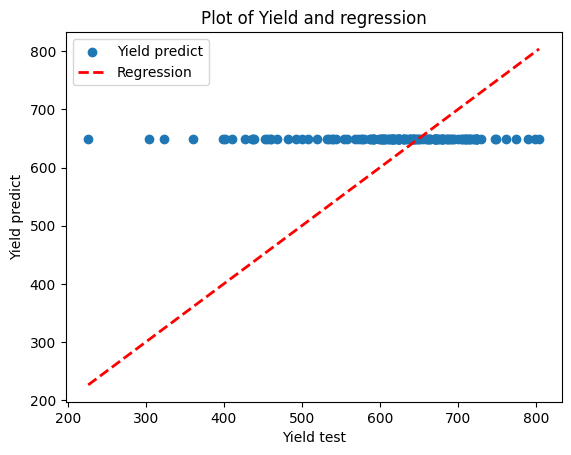

In [8]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

In [9]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
#metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [10]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 226.1118,
  'predict': 649.7553600095393,
  'error': 1.8736021738340916},
 {'truth': 304.5419,
  'predict': 649.7452005334447,
  'error': 1.1335166048857144},
 {'truth': 322.9881,
  'predict': 649.7589948183589,
  'error': 1.0117118705560948},
 {'truth': 360.0, 'predict': 649.7615463557319, 'error': 0.8048931843214774},
 {'truth': 398.2896,
  'predict': 649.7654334028933,
  'error': 0.6313894046013085},
 {'truth': 400.8056, 'predict': 649.7684331486603, 'error': 0.621156074537532},
 {'truth': 409.865, 'predict': 649.7626309991842, 'error': 0.5853088968298933},
 {'truth': 427.0, 'predict': 649.7568633132968, 'error': 0.5216788367992898},
 {'truth': 436.0, 'predict': 649.7691030820349, 'error': 0.4902961079863186},
 {'truth': 437.0, 'predict': 649.7635272624931, 'error': 0.4868730600972382},
 {'truth': 438.9351,
  'predict': 649.7603572927187,
  'error': 0.48031077326173904},
 {'truth': 453.0, 'predict': 649.7712354050713, 'error': 0.434373588090665},
 {'truth': 455.805, 'pred